# 12 - Report figures and tables

Consolidates every plot/table built for the report into one place. Every cell loads from cache created in an earlier script.

## Setup

In [1]:
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, roc_auc_score

BASEPATH = "../data"
FIGDIR = "../report/figures"

_LM_DIR = "/usr/local/texlive/2025/texmf-dist/fonts/opentype/public/lm"
if os.path.isdir(_LM_DIR):
    for _fname in [
        "lmroman10-regular.otf", "lmroman10-bold.otf", "lmroman10-italic.otf"
    ]:
        fm.fontManager.addfont(f"{_LM_DIR}/{_fname}")
    plt.rcParams["font.serif"] = ["Latin Modern Roman"]
else:
    plt.rcParams["font.serif"] = ["cmr10"]  # fallback if not installed
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.formatter.use_mathtext"] = True

## Table A.1 -- Systemwide OTP by year

Source: `8_otp_by_year.parquet`, cached by `08_descriptive.ipynb`. Backs Section 3.1's "worst-performing
year" claim (76.23% for 2025) and Appendix A.6.

In [2]:
otp_by_year = pd.read_parquet(f"{BASEPATH}/8_otp_by_year.parquet")
otp_by_year_display = otp_by_year.copy()
otp_by_year_display["otp"] = (
    (otp_by_year_display["otp"] * 100).round(2).astype(str) + "%"
)
otp_by_year_display

,otp,n_runs
year,,
2017,79.98%,238296
2018,80.7%,138298
2019,84.31%,190170
2020,87.19%,111370
2021,85.38%,142884
2022,85.77%,174031
2023,85.66%,175481
2024,80.8%,187033
2025,76.23%,194191


## Figure: line-level OTP trend (Section 4.1)

Source: `8_line_year_otp.parquet`, cached by `08_descriptive.ipynb`. Four lines highlighted: Paoli/
Thorndale (worst) and Cynwyd (best) match the two extremes already named in 4.1's prose; Media/Elwyn +
Media/Wawa are highlighted together since the Aug 2022 extension created two briefly coexisting services
on the same corridor (not a rename) -- see `08_descriptive.ipynb`'s own note for the full explanation.

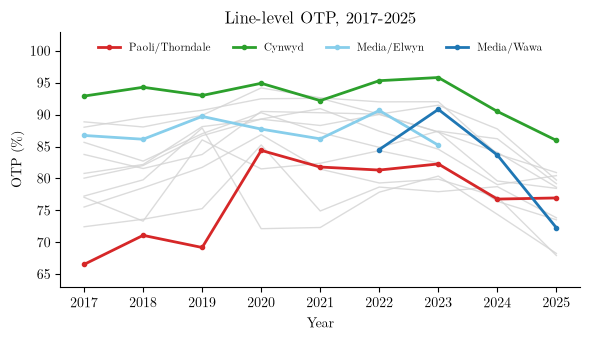

In [3]:
line_year_otp = pd.read_parquet(f"{BASEPATH}/8_line_year_otp.parquet")

HIGHLIGHT_LINES = {
    "Paoli/Thorndale": "tab:red",
    "Cynwyd": "tab:green",
    "Media/Elwyn": "skyblue",
    "Media/Wawa": "tab:blue",
}

fig, ax = plt.subplots(figsize = (6, 3.5))
for line in line_year_otp.index:
    if line in HIGHLIGHT_LINES:
        continue
    ax.plot(
        line_year_otp.columns, line_year_otp.loc[line] * 100,
        color = "lightgray", linewidth = 1, alpha = 0.8, zorder = 1,
    )
for line, color in HIGHLIGHT_LINES.items():
    ax.plot(
        line_year_otp.columns, line_year_otp.loc[line] * 100,
        color = color, linewidth = 2, marker = "o", markersize = 3,
        label = line, zorder = 2,
    )

ax.set_xlabel("Year")
ax.set_ylabel("OTP (%)")
ax.set_title("Line-level OTP, 2017-2025")
ax.set_ylim(63, 103)
ax.legend(
    loc = "upper center", bbox_to_anchor = (0.5, 1.0), fontsize = 8,
    frameon = False, ncol = 4,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/otp_by_line_trend.png", dpi = 200, bbox_inches = "tight")
plt.show()

## Appendix D.2 -- OTP threshold sensitivity

Source: `8_threshold_sensitivity.parquet`, cached by `08_descriptive.ipynb`. Backs Section 5.2's "3% to
4% of all observed runs finish just past the OTP threshold" claim (the 6-to-7-minute reclassification).

In [4]:
threshold_sensitivity = pd.read_parquet(
    f"{BASEPATH}/8_threshold_sensitivity.parquet"
)
n_total = int(threshold_sensitivity["n_total"].iloc[0])
reclassified = int(threshold_sensitivity["reclassified_6to7"].iloc[0])

display_df = threshold_sensitivity[["threshold_min", "otp", "n_late"]].copy()
display_df["otp"] = (display_df["otp"] * 100).round(2).astype(str) + "%"
print(display_df.to_string(index = False))
print(
    f"\nRuns reclassified 6min->7min: {reclassified:,} "
    f"({reclassified / n_total:.2%} of all {n_total:,} runs)"
)

 threshold_min    otp  n_late
             5 78.09%  339940
             6 82.51%  271403
             7 85.78%  220587
            10 91.76%  127839

Runs reclassified 6min->7min: 50,816 (3.27% of all 1,551,754 runs)


## Figure: grouped SHAP importance (Section 3.5, Appendix B.5)

Source: `10_shap_grouped_ranking.parquet`, cached by `10_feature_importance.ipynb`. Colors distinguish
single features (blue) from correlated families summed together (orange) -- see B.5 for the
curly-brace-vs-wildcard naming convention behind the grouped labels.

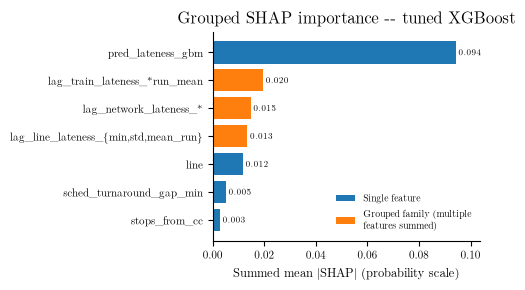

In [5]:
b5_ranking = pd.read_parquet(f"{BASEPATH}/10_shap_grouped_ranking.parquet")

fig, ax = plt.subplots(figsize = (5, 3))
colors = [
    "tab:orange" if n > 1 else "tab:blue" for n in b5_ranking["n_features"]
]
bars = ax.barh(b5_ranking.index, b5_ranking["importance"], color = colors)
ax.bar_label(bars, fmt = "%.3f", fontsize = 6.5, padding = 2)
ax.set_xlabel("Summed mean |SHAP| (probability scale)", fontsize = 9)
ax.set_title("Grouped SHAP importance -- tuned XGBoost")
ax.tick_params(axis = "both", labelsize = 8)
ax.margins(x = 0.1)
ax.spines[["top", "right"]].set_visible(False)
legend_handles = [
    Patch(facecolor = "tab:blue", label = "Single feature"),
    Patch(
        facecolor = "tab:orange",
        label = "Grouped family (multiple\nfeatures summed)",
    ),
]
ax.legend(
    handles = legend_handles, loc = "lower right", fontsize = 7,
    frameon = False,
)
plt.tight_layout()
plt.savefig(
    f"{FIGDIR}/shap_grouped_importance.png", dpi = 200, bbox_inches = "tight"
)
plt.show()

## Figure variant: grouped SHAP importance with plain-English labels

Same data as above (`10_shap_grouped_ranking.parquet`), with feature/group names swapped for
plain-English descriptions -- saved separately as `shap_grouped_importance2.png` so both versions stay
available while a final call is made. Label definitions checked directly against `07_reduce_for_modeling.ipynb`:
`lag_train_lateness_*run_mean` is the same physical train's own trailing lateness (1/3/5/10-run mean,
regardless of line); `lag_network_lateness_*` is systemwide (all lines) trailing mean lateness over
30min/2hr/6hr clock-time windows, not run-windowed; `lag_line_lateness_{min,std,mean_run}` is the single
immediately-preceding run on the same line+direction -- its terminal lateness, the volatility across that
run's pings, and that run's own mean lateness (first-run-of-day rows fall back to a trailing 4-week
same-day-of-week average).

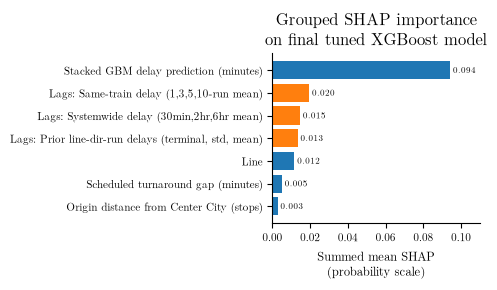

In [6]:
LABEL_MAP = {
    "pred_lateness_gbm": "Stacked GBM delay prediction (minutes)",
    "lag_train_lateness_*run_mean": (
        "Lags: Same-train delay (1,3,5,10-run mean)"
    ),
    "lag_network_lateness_*": (
        "Lags: Systemwide delay (30min,2hr,6hr mean)"
    ),
    "lag_line_lateness_{min,std,mean_run}": (
        "Lags: Prior line-dir-run delays (terminal, std, mean)"
    ),
    "line": "Line",
    "sched_turnaround_gap_min": "Scheduled turnaround gap (minutes)",
    "stops_from_cc": "Origin distance from Center City (stops)",
}
b5_ranking_labeled = b5_ranking.rename(index = LABEL_MAP)

fig, ax = plt.subplots(figsize = (5, 3))
colors = [
    "tab:orange" if n > 1 else "tab:blue"
    for n in b5_ranking_labeled["n_features"]
]
bars = ax.barh(
    b5_ranking_labeled.index, b5_ranking_labeled["importance"], color = colors
)
ax.bar_label(bars, fmt = "%.3f", fontsize = 6.5, padding = 2)
ax.set_xlabel("Summed mean SHAP\n(probability scale)", fontsize = 9)
ax.set_title("Grouped SHAP importance\non final tuned XGBoost model")
ax.tick_params(axis = "both", labelsize = 8)
ax.set_xlim(0, 0.11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(
    f"{FIGDIR}/shap_grouped_importance2.png", dpi = 200, bbox_inches = "tight"
)
plt.show()

## Figure: ROC curve deltas vs. final model (Section 3.4, candidate figure)

Source: `9d_predictions_test.parquet`, cached by `09d_ensemble.ipynb`. Shows each alternative model's
TPR relative to the final model (tuned XGBoost) at matched FPR, rather than overlaid raw ROC curves --
the near-identical AUCs among XGBoost/tuned-weight-ensemble/stacking make raw curves visually
indistinguishable regardless of line weight, so this reframes the same comparison in a legible way.
Not yet decided whether this goes in the final report -- kept here as the canonical version pending
that decision.

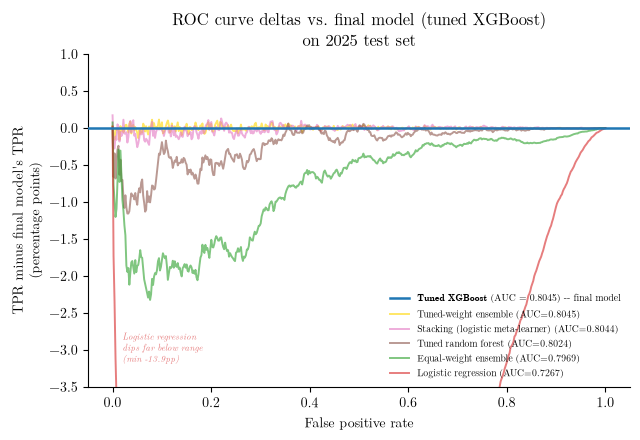

In [7]:
import numpy as np

pred_test = pd.read_parquet(f"{BASEPATH}/9d_predictions_test.parquet")

fpr_grid = np.linspace(0, 1, 500)
fpr_ref, tpr_ref, _ = roc_curve(pred_test["is_otp"], pred_test["p_xgb"])
tpr_ref_interp = np.interp(fpr_grid, fpr_ref, tpr_ref)

MODELS = [
    ("Tuned-weight ensemble", "p_ensemble_tuned", "gold", 0.8045),
    ("Stacking (logistic meta-learner)", "p_ensemble_meta", "tab:pink", 0.8044),
    ("Tuned random forest", "p_rf", "tab:brown", 0.8024),
    ("Equal-weight ensemble", "p_ensemble_equal", "tab:green", 0.7969),
    ("Logistic regression", "p_logit", "tab:red", 0.7267),
]

fig, ax = plt.subplots(figsize = (6.5, 4.5))
ax.axhline(
    0, color = "tab:blue", linewidth = 1.8, alpha = 1.0,
    label = r"$\bf{Tuned\ XGBoost}$ (AUC = 0.8045) -- final model", zorder = 5,
)
for name, col, color, auc in MODELS:
    fpr, tpr, _ = roc_curve(pred_test["is_otp"], pred_test[col])
    tpr_interp = np.interp(fpr_grid, fpr, tpr)
    delta = (tpr_interp - tpr_ref_interp) * 100
    ax.plot(
        fpr_grid, delta, color = color, linewidth = 1.4, alpha = 0.6,
        label = f"{name} (AUC={auc:.4f})", zorder = 3,
    )

ax.set_ylim(-3.5, 1.0)
ax.set_xlabel("False positive rate")
ax.set_ylabel("TPR minus final model's TPR\n(percentage points)")
ax.set_title(
    "ROC curve deltas vs. final model (tuned XGBoost)\non 2025 test set"
)
ax.legend(loc = "lower right", fontsize = 7, frameon = False, ncol = 1)
ax.spines[["top", "right"]].set_visible(False)
ax.text(
    0.02, -2.75, "Logistic regression\ndips far below range\n(min -13.9pp)",
    fontsize = 6.5, color = "tab:red", alpha = 0.6, ha = "left", va = "top",
    style = "italic",
)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/roc_delta_alpha2.png", dpi = 200, bbox_inches = "tight")
plt.show()

## Table 2 -- Time lost per segment, by segment type (Section 4.3)

Source: `11_boundary_hop_table.parquet`, cached by `11_spatial_delay_patterns.ipynb` Section 4b.

In [8]:
boundary_table = pd.read_parquet(
    f"{BASEPATH}/11_boundary_hop_table.parquet"
)
LABELS = {
    "entering_amtrak": "Entering Amtrak-owned track",
    "exiting_amtrak": "Exiting Amtrak-owned track",
    "within_amtrak": "Fully inside Amtrak-owned track",
    "within_septa": "Fully inside SEPTA-owned track",
}
table2_display = boundary_table.loc[list(LABELS.keys())].copy()
table2_display.index = [LABELS[i] for i in table2_display.index]
table2_display["Avg. time lost crossing it"] = table2_display[
    "mean_delta_min"
].map(lambda v: f"{v:+.2f} min")
table2_display["Segments observed"] = table2_display["n_stop_visits"].map(
    lambda v: f"{v:,}"
)
table2_display[["Avg. time lost crossing it", "Segments observed"]]

,Avg. time lost crossing it,Segments observed
Entering Amtrak-owned track,+0.85 min,"529,825"
Exiting Amtrak-owned track,+0.74 min,"421,106"
Fully inside Amtrak-owned track,+0.12 min,"5,925,611"
Fully inside SEPTA-owned track,+0.15 min,"12,886,549"


## Appendix C.2/C.3 -- boundary-crossing significance

Source: `11_boundary_significance.parquet`, cached by `11_spatial_delay_patterns.ipynb` Section 4b.
Coefficients are relative to the `within_septa` reference category.

In [9]:
boundary_significance = pd.read_parquet(
    f"{BASEPATH}/11_boundary_significance.parquet"
)
sig_display = boundary_significance.set_index("hop_type").copy()
sig_display.index = [LABELS.get(f"{i}", i) for i in sig_display.index]
for col in ["coef_no_fe", "coef_line_fe"]:
    sig_display[col] = sig_display[col].map(lambda v: f"{v:+.3f}")
for col in ["p_no_fe", "p_line_fe"]:
    sig_display[col] = sig_display[col].map(lambda v: f"{v:.3f}")
sig_display

,coef_no_fe,p_no_fe,coef_line_fe,p_line_fe
Entering Amtrak-owned track,+0.645,0.000,+0.776,0.000
Exiting Amtrak-owned track,+0.545,0.128,+0.675,0.066
Fully inside Amtrak-owned track,-0.010,0.697,+0.146,0.015


## Figure: Amtrak ownership map (Section 4.3, candidate figure)

Source: `11_hop_geometries.parquet`, `11_station_points.parquet`, `11_termini.parquet`, all
cached by `11_spatial_delay_patterns.ipynb` Section 4d. Known issue, not yet fixed: terminus labels
overlap badly near Center City where branches converge, especially Inbound -- not report-ready as-is.

/var/folders/lt/dz18w_1d1dsdjlxdkcpp_cxh0000gn/T/ipykernel_97185/3292964312.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


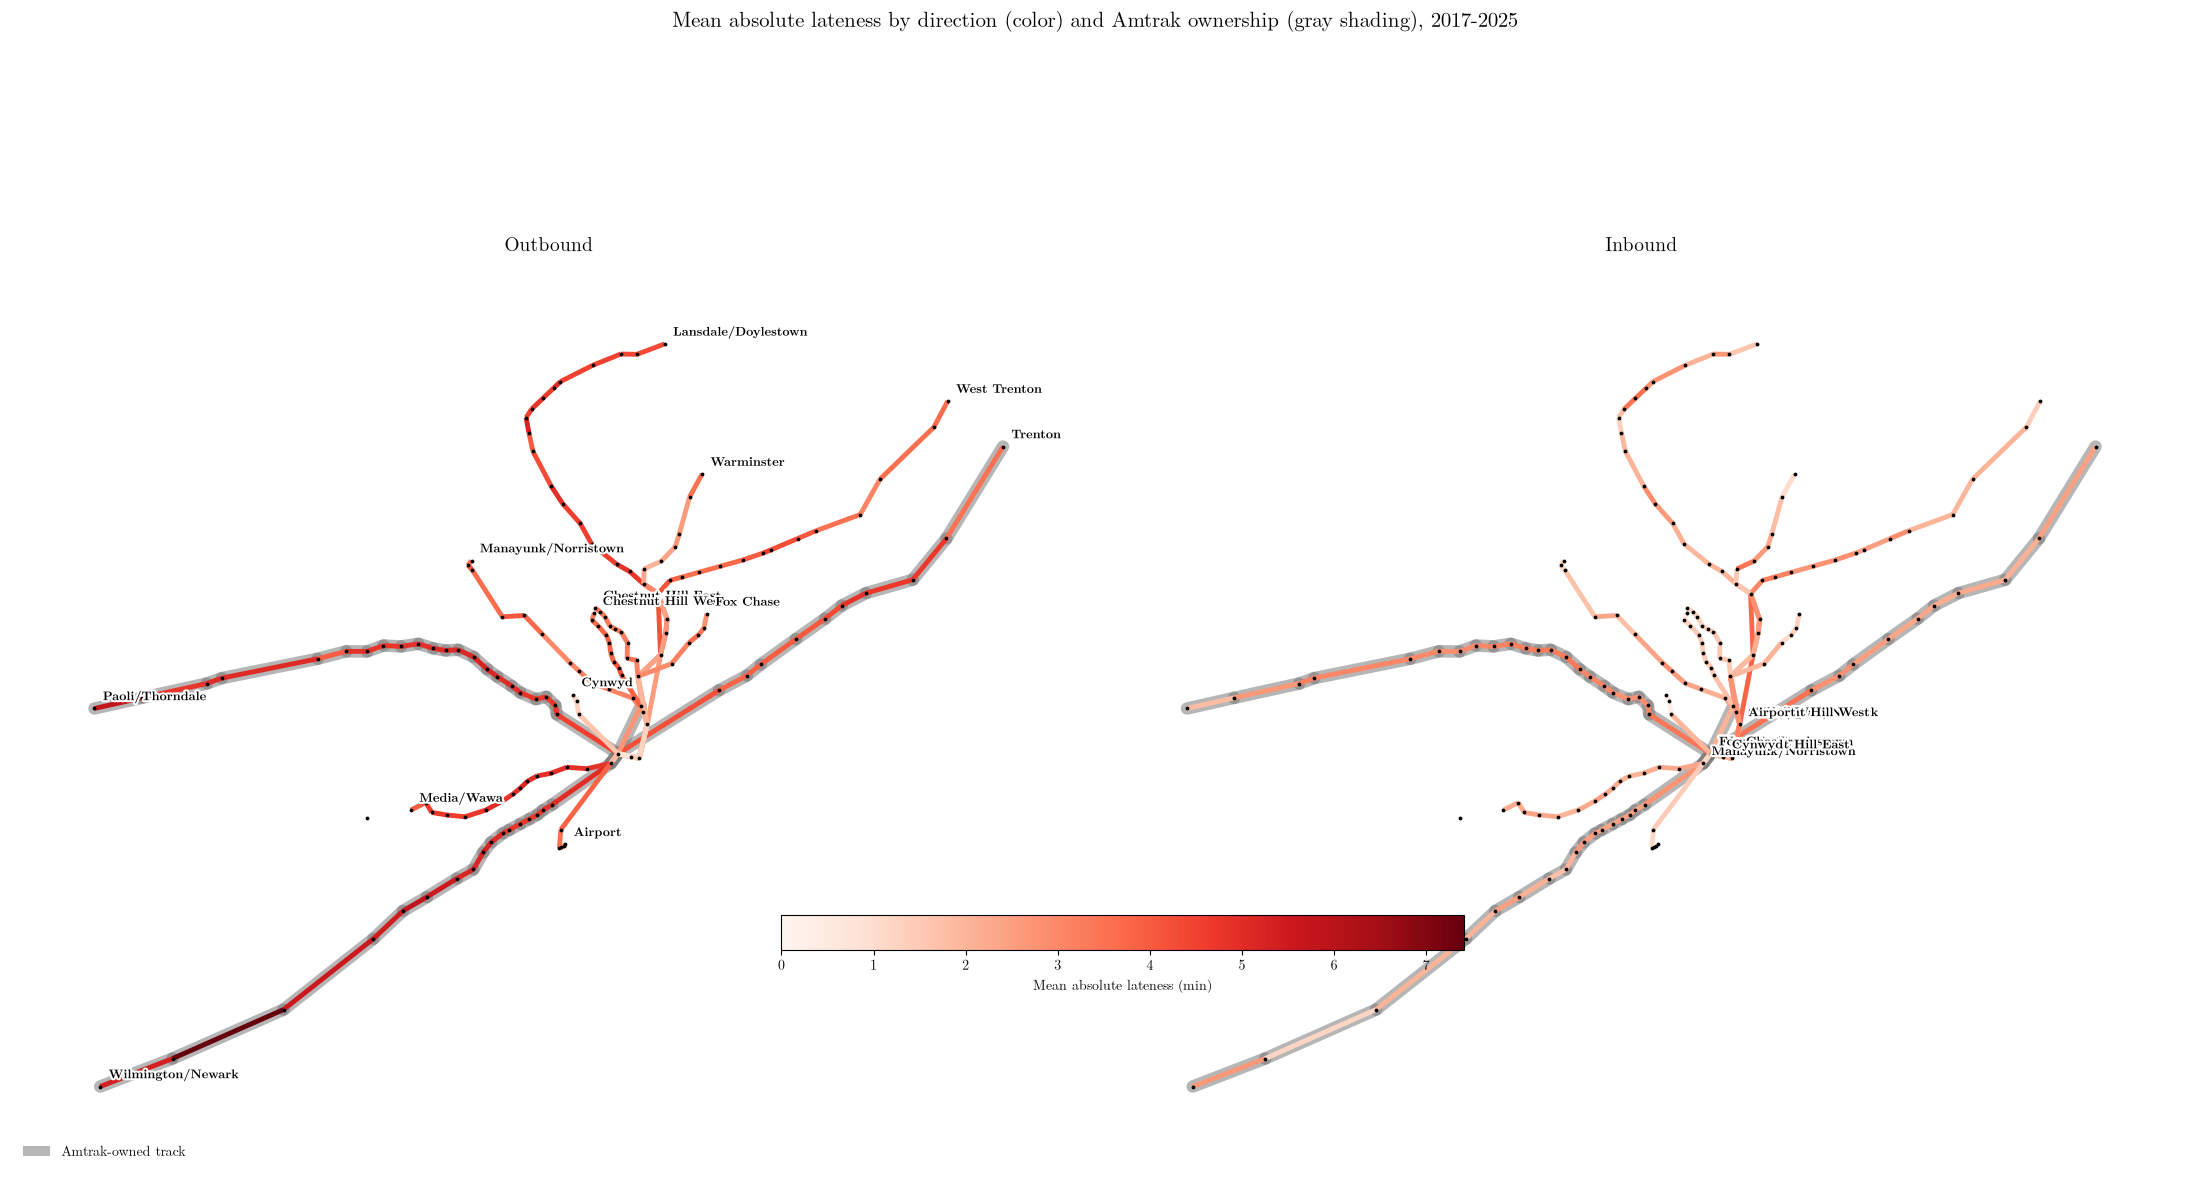

In [10]:
gdf_hops_geo = gpd.read_parquet(f"{BASEPATH}/11_hop_geometries.parquet")
stn_points = gpd.read_parquet(
    f"{BASEPATH}/11_station_points.parquet"
).set_index("stop_id")
termini = pd.read_parquet(f"{BASEPATH}/11_termini.parquet")

minx, miny, maxx, maxy = stn_points.total_bounds
margin = 8000
vmax_abs = gdf_hops_geo["mean_abs_delay"].max()

fig, axes = plt.subplots(1, 2, figsize = (22, 12))
for ax, direction in zip(axes, ["Outbound", "Inbound"]):
    sub = gdf_hops_geo[gdf_hops_geo["real_direction"] == direction]
    sub[sub["is_amtrak"] == 1].plot(
        ax = ax, color = "#7a7a7a", alpha = 0.55, linewidth = 9,
        zorder = 1, capstyle = "round",
    )
    sub[sub["mean_abs_delay"].notna()].plot(
        ax = ax, column = "mean_abs_delay", cmap = "Reds", vmin = 0,
        vmax = vmax_abs, linewidth = 3.5, zorder = 2,
    )
    stn_points.plot(ax = ax, color = "black", markersize = 3, zorder = 3)
    dir_termini = termini[termini["real_direction"] == direction]
    for _, r in dir_termini.iterrows():
        term_pt = stn_points.loc[r["terminus_stop_id"], "geometry"]
        ax.annotate(
            r["line"], (term_pt.x, term_pt.y),
            xytext = (6, 6), textcoords = "offset points",
            fontsize = 9, fontweight = "bold", zorder = 4,
            path_effects = [
                pe.withStroke(linewidth = 3, foreground = "white")
            ],
        )
    ax.set_xlim(minx - margin, maxx + margin)
    ax.set_ylim(miny - margin, maxy + margin)
    ax.set_title(direction, fontsize = 14)
    ax.set_axis_off()

sm_map = plt.cm.ScalarMappable(cmap = "Reds", norm = plt.Normalize(0, vmax_abs))
sm_map.set_array([])
cbar = fig.colorbar(
    sm_map, ax = axes, shrink = 0.4, pad = 0.02,
    orientation = "horizontal", location = "bottom",
)
cbar.set_label("Mean absolute lateness (min)")
axes[0].legend(
    handles = [
        Patch(
            facecolor = "#7a7a7a", alpha = 0.55, label = "Amtrak-owned track"
        )
    ],
    loc = "lower left", frameon = False, fontsize = 10,
)
fig.suptitle(
    "Mean absolute lateness by direction (color) and Amtrak ownership "
    "(gray shading), 2017-2025",
    fontsize = 15,
)
plt.tight_layout()
plt.savefig(
    f"{FIGDIR}/amtrak_ownership_map.png", dpi = 150, bbox_inches = "tight"
)
plt.show()

## Figure: line schematic, Outbound only, all 14 lines (Section 4.2/4.3, candidate figure)

Source: `11_hops_flat.parquet`, cached by `11_spatial_delay_patterns.ipynb` Section 4c. Small-multiples
heatmap, one column per line, Center City at the top of every column (shared stop-count scale) -- avoids
the geographic map's label-overlap problem entirely since columns don't compete for space geographically.
Amtrak-owned stretch outlined in black on the 6 lines that have one. Two variants: mean absolute lateness
(level) and mean incremental delay (accumulated per hop) -- the latter uses a diverging scale since
individual stops can show net time *recovered*, not just lost.

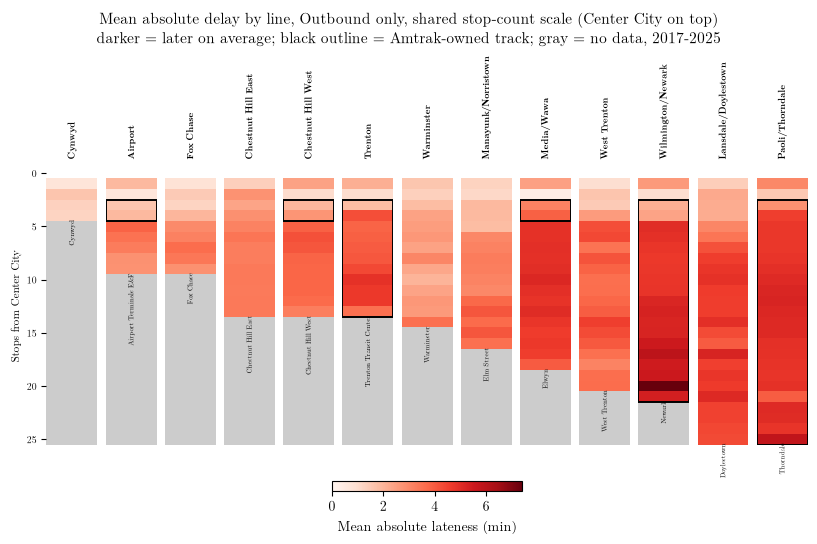

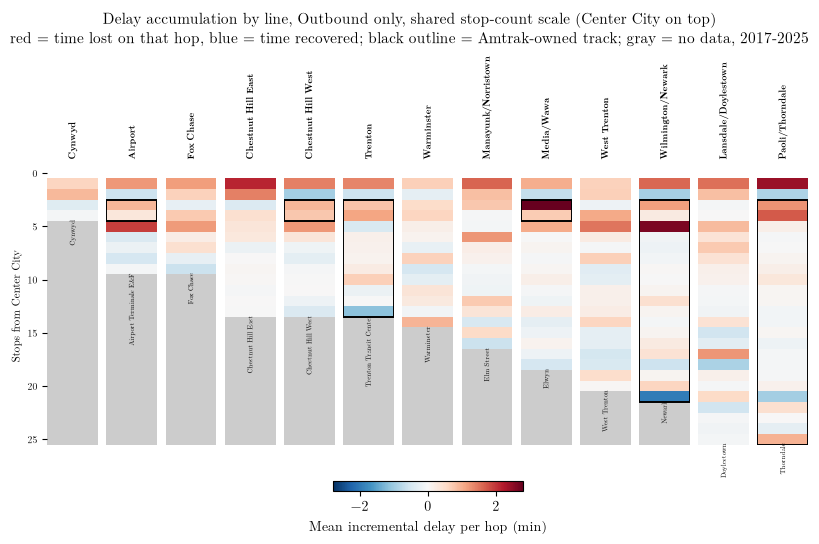

In [11]:
hops_flat = pd.read_parquet(f"{BASEPATH}/11_hops_flat.parquet")
outbound_flat = hops_flat[hops_flat["real_direction"] == "Outbound"].copy()
outbound_flat["stop_position"] = outbound_flat["stop_position"].astype(int)
line_order = (
    outbound_flat.groupby("line")["stop_position"].max().sort_values().index
).tolist()
max_stops = outbound_flat["stop_position"].max() + 1

def plot_line_schematic(
    value_col, cmap, vmin, vmax, cbar_label, title, filename
):
    strip_data, amtrak_ranges = {}, {}
    for line in line_order:
        sub = outbound_flat[outbound_flat["line"] == line].sort_values(
            "stop_position"
        )
        strip_data[line] = (
            sub["stop_position"].to_numpy(), sub[value_col].to_numpy()
        )
        flagged = sub[sub["is_amtrak"]]
        if len(flagged) > 0:
            amtrak_ranges[line] = (
                flagged["stop_position"].min(), flagged["stop_position"].max()
            )

    n = len(line_order)
    fig, axes = plt.subplots(
        1, n, figsize = (n * 0.62, max_stops * 0.12 + 2.2),
        constrained_layout = True,
    )
    for i, (ax, line) in enumerate(zip(axes, line_order)):
        positions, vals = strip_data[line]
        col = np.full((max_stops, 1), np.nan)
        col[positions, 0] = vals
        ax.imshow(col, cmap = cmap, vmin = vmin, vmax = vmax, aspect = "auto")
        for j in range(max_stops):
            if np.isnan(col[j, 0]) and j != 0:
                ax.add_patch(plt.Rectangle(
                    (-0.5, j - 0.5), 1, 1,
                    facecolor = "#cccccc", edgecolor = "none",
                ))
        if line in amtrak_ranges:
            lo, hi = amtrak_ranges[line]
            ax.add_patch(plt.Rectangle(
                (-0.5, lo - 0.5), 1, hi - lo + 1, facecolor = "none",
                edgecolor = "black", linewidth = 1.4, zorder = 5,
            ))
        ax.set_ylim(max_stops - 0.5, -0.5)
        ax.set_xticks([])
        if i == 0:
            yticks = list(range(0, max_stops, 5))
            ax.set_yticks(yticks)
            ax.set_yticklabels(yticks, fontsize = 7)
            ax.set_ylabel("Stops from Center City", fontsize = 8)
        else:
            ax.set_yticks([])
        ax.set_title(
            line, fontsize = 6.5, fontweight = "bold", rotation = 90,
            ha = "center", va = "bottom",
        )
        term_row = (
            outbound_flat[outbound_flat["line"] == line]
            .sort_values("stop_position")
            .iloc[-1]
        )
        ax.annotate(
            term_row["stop_name"], (0, term_row["stop_position"]),
            xytext = (0, -3), textcoords = "offset points",
            fontsize = 5, rotation = 90, ha = "center", va = "top",
        )
        for spine in ax.spines.values():
            spine.set_visible(False)

    fig.suptitle(title, fontsize = 11)
    sm = plt.cm.ScalarMappable(cmap = cmap, norm = plt.Normalize(vmin, vmax))
    sm.set_array([])
    cbar = fig.colorbar(
        sm, ax = axes, shrink = 0.25, pad = 0.01,
        orientation = "horizontal", location = "bottom",
    )
    cbar.set_label(cbar_label)
    plt.savefig(f"{FIGDIR}/{filename}", dpi = 180, bbox_inches = "tight")
    plt.show()

mal_max = outbound_flat["mean_abs_delay"].max()
plot_line_schematic(
    "mean_abs_delay", "Reds", 0, mal_max, "Mean absolute lateness (min)",
    "Mean absolute delay by line, Outbound only, shared stop-count scale "
    "(Center City on top)\n"
    "darker = later on average; black outline = Amtrak-owned track; "
    "gray = no data, 2017-2025",
    "amtrak_schematic_outbound_mal.png",
)

delta_abs_max = outbound_flat["mean_delta"].abs().max()
plot_line_schematic(
    "mean_delta", "RdBu_r", -delta_abs_max, delta_abs_max,
    "Mean incremental delay per hop (min)",
    "Delay accumulation by line, Outbound only, shared stop-count scale "
    "(Center City on top)\n"
    "red = time lost on that hop, blue = time recovered; black outline = "
    "Amtrak-owned track; gray = no data, 2017-2025",
    "amtrak_schematic_outbound.png",
)